In [38]:
import glob
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A # La référence pour l'augmentation d'images
from albumentations.pytorch import ToTensorV2

In [3]:
# Astuce : On cherche d'abord les masques car ils sont faciles à identifier
mask_files = glob.glob('data/*/*_mask.tif')

In [4]:
data_list = []
for mask_path in mask_files:
    # Logique pour retrouver l'image source associée au masque
    img_path = mask_path.replace('_mask', '')
    
    data_list.append({'image_path': img_path, 'mask_path': mask_path})

df = pd.DataFrame(data_list)

In [5]:
df.head()

,image_path,mask_path
0,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
1,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
2,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
3,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
4,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...


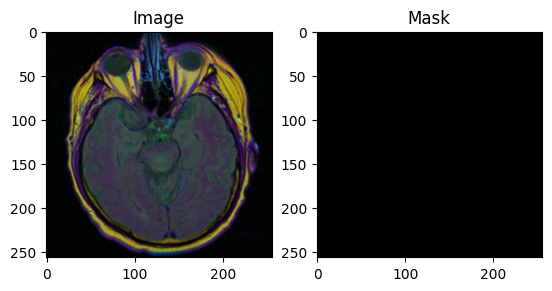

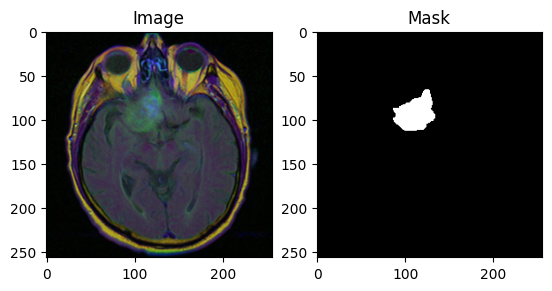

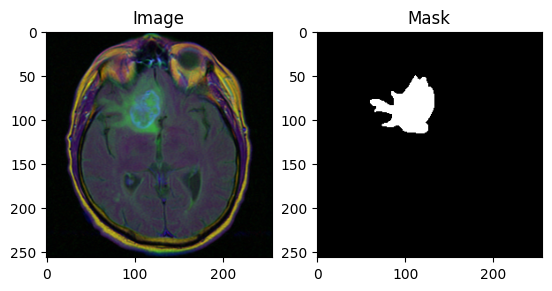

In [6]:
for i in range(3):
    image = cv2.imread(df['image_path'].iloc[i])
    mask = cv2.imread(df['mask_path'].iloc[i])
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Image')
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
    plt.title('Mask')
    plt.show()

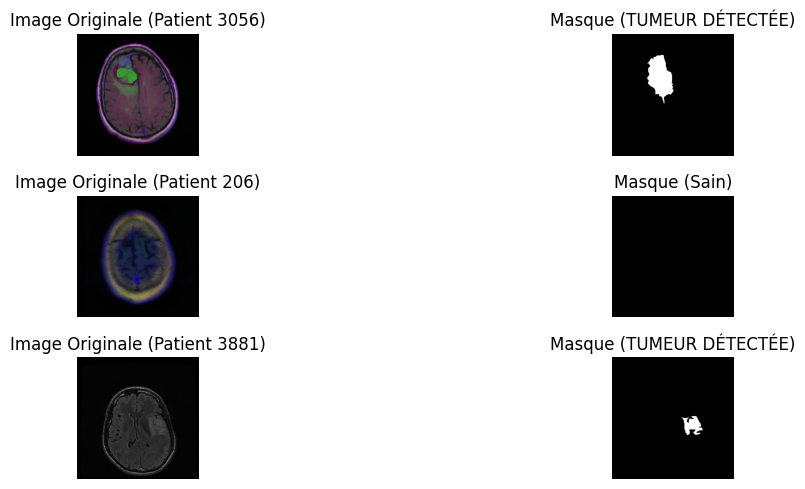

In [7]:
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

def visualize_random_sample(df):
    """
    Affiche 3 paires aléatoires (Image + Masque) tirées du DataFrame.
    """
    # On configure la taille de l'affichage
    plt.figure(figsize=(15, 5))
    
    # On tire 3 index au hasard
    random_indices = random.sample(range(len(df)), 3)
    
    for i, idx in enumerate(random_indices):
        # 1. Récupérer les chemins
        img_path = df.iloc[idx]['image_path']
        mask_path = df.iloc[idx]['mask_path']
        
        # 2. Lire les images
        # cv2 lit en BGR par défaut, on convertit en RGB pour l'affichage correct
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Le masque est en niveaux de gris
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # 3. Affichage Image Originale
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(image)
        plt.title(f"Image Originale (Patient {idx})")
        plt.axis("off")
        
        # 4. Affichage Masque (Vérité Terrain)
        plt.subplot(3, 2, 2*i + 2)
        plt.imshow(mask, cmap='gray') # 'gray' pour voir le noir et blanc correctement
        
        # Petit check technique : y a-t-il une tumeur ?
        has_tumor = np.max(mask) > 0
        status = "TUMEUR DÉTECTÉE" if has_tumor else "Sain"
        plt.title(f"Masque ({status})")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Exécuter la fonction
visualize_random_sample(df)

In [8]:
class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        Args:
            df (DataFrame): Le dataframe contenant les chemins
            transform (albumentations.Compose): Les transformations à appliquer
        """
        self.df = df
        self.transform = transform

    def __len__(self):
        # OBLIGATOIRE : Renvoie la taille totale du dataset
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df.iloc[index]['image_path']
        mask_path = self.df.iloc[index]['mask_path']

        # Lecture de l'image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Lecture du masque
        # On garde les valeurs brutes (0 ou 255) pour l'instant
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # APPLICATION DES TRANSFORMATIONS & AUGMENTATION
        if self.transform:
            # Albumentations gère l'image et le masque en même temps !
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Si pas de transformation, on convertit juste en Tensor manuellement
            # Normalisation 0-1 et permutation des axes (H, W, C) -> (C, H, W)
            image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0
            mask = torch.from_numpy(mask).float().unsqueeze(0) / 255.0

        # Post-traitement critique pour le masque :
        # Le masque sort souvent sans dimension de canal (H, W), 
        # mais le réseau veut (1, H, W).
        # De plus, on normalise le masque pour qu'il soit binaire (0.0 ou 1.0)
        
        if len(mask.shape) == 2: # Si c'est juste (H, W)
             mask = mask.unsqueeze(0) # Devient (1, H, W)
        
        # On s'assure que le masque est bien en float et normalisé (0 ou 1)
        # Certains masques ont 255 comme valeur max, d'autres 1.
        mask = mask.float()
        mask[mask > 0] = 1.0 
        
        return image, mask

In [ ]:
# Définition des constantes
IMAGE_SIZE = 256 # Standard pour U-Net

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Statistiques officielles ImageNet (OBLIGATOIRE pour Transfer Learning)
mean_imagenet = [0.485, 0.456, 0.406]
std_imagenet = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    # Normalisation stricte pour ResNet
    A.Normalize(mean=mean_imagenet, std=std_imagenet, max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=mean_imagenet, std=std_imagenet, max_pixel_value=255.0),
    ToTensorV2(),
])

In [21]:
import os
from sklearn.model_selection import train_test_split

# 1. Extraction de l'ID du patient (basé sur le dossier parent)
# Structure typique : .../TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12.tif
# L'ID unique pour le "Group Split" sera le nom du dossier (Patient + Date d'examen)
df['patient_id'] = df['image_path'].apply(lambda x: os.path.dirname(x))

In [24]:
# 2. Récupération des IDs uniques
patient_ids = df['patient_id'].unique()
print(f"Nombre total de patients (scans) distincts : {len(patient_ids)}")

# 3. Séparation des IDs (Train: 80%, Val: 10%, Test: 10%)
# D'abord on sépare Train (80%) et le Reste (20%)
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)

# Ensuite on coupe le Reste en deux parts égales (10% Val, 10% Test)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

Nombre total de patients (scans) distincts : 110


In [28]:
# 4. Création des DataFrames finaux basés sur ces IDs
train_df = df[df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = df[df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df = df[df['patient_id'].isin(test_ids)].reset_index(drop=True)

print(f"--- Résultat du Split ---")
print(f"Train Set : {len(train_df)} images ({len(train_ids)} patients)")
print(f"Val Set   : {len(val_df)} images ({len(val_ids)} patients)")
print(f"Test Set  : {len(test_df)} images ({len(test_ids)} patients)")

--- Résultat du Split ---
Train Set : 3151 images (88 patients)
Val Set   : 429 images (11 patients)
Test Set  : 349 images (11 patients)


In [29]:
train_dataset = MRIDataset(train_df, train_transform)
val_dataset = MRIDataset(val_df, val_transform)
test_dataset = MRIDataset(test_df, val_transform)

In [30]:
BATCH_SIZE = 16

In [36]:
train_dataloader = DataLoader(
    train_dataset,
    BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

val_dataloader = DataLoader(
    val_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

test_dataloader = DataLoader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [37]:
# 1. Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du device : {device}")

Utilisation du device : cpu


In [39]:
from model import UNet

# 2. Créer le modèle
model = UNet(n_channels=3, n_classes=1).to(device)

# 3. L'Optimiseur (Adam est le standard)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # Learning rate petit pour la stabilité

# 4. La Loss Function (CRUCIAL)
# Comme nous n'avons qu'une seule classe (Tumeur oui/non), nous utilisons BCEWithLogitsLoss.
# Elle combine une Sigmoid + Binary Cross Entropy. C'est plus stable numériquement.
criterion = nn.BCEWithLogitsLoss()

In [40]:
# On crée une fausse image (Batch=1, Channels=3, H=256, W=256)
dummy_input = torch.randn(1, 3, 256, 256).to(device)

# On la passe dans le modèle
output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

# Vérification : L'output doit être (1, 1, 256, 256)
assert output.shape == (1, 1, 256, 256), "Erreur de dimension en sortie !"
print("Test réussi ! Le modèle est prêt.")

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Test réussi ! Le modèle est prêt.
